# Ecuación de Burger
 

## Problem Setup

The Burger one-dimentional  problem:

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2},\qquad\qquad x\in[-1,1],\qquad t\in[0,1]$$


Con las siguientes condiciones de frontera:<br>
- Dirichlet $$u(-1,t)=u(1,t)=0$$
- Initial Conditions $$u(x,0)=-sin(\pi x)$$

Donde,
- $\nu$ es el coeficiente de viscosidad. Tomado acá como $\nu==0.01/\pi$


In [6]:
import torch as tr

In [1]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
dde.backend.backend_name = "pytorch"

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [5]:
# Plot settings
plt.close('all')
plt.rcParams['font.family'] = "serif"
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

## Paso 1. Solución de red

In [3]:
def pde(x, y):
    dy_xx    = dde.grad.hessian(y,x)      # d2u/dx2
    dy_dxxxx = dde.grad.hessian(dy_xx,x)  # d4u/dx4
    return dy_dxxxx + 1

In [4]:
## Exact solution
def func(x):
    return - x**4 / 24. + x**3 / 6. - x**2 / 4.


In [5]:
## Dirichlet and Neumann Conditions
# En este caso, debido a la peculiaridad de que neuman y dirichlet ambas zero en x=0, por el planteamiento del
# problema, en ambos casos, se usa la misma función.

def boundary_value_l(x):
    return 0

def boundary_l(x,on_boundary):
    return on_boundary and dde.utils.isclose(x[0],0)


## Main PINN Model

In [8]:
geom = dde.geometry.Interval(-1,1)
timedomain = dde.geometry.TimeDomain(0,0.99)
geotime = dde.geometry.GeometryXTime(geom,timedomain)

In [9]:
bc_dbc = dde.icbc.DirichletBC(geom, boundary_value_l, boundary_l)
bc_nbc = dde.icbc.NeumannBC(geom, boundary_value_l, boundary_l)


# Operator Boundary Condition

In [10]:
def ddy(x,y):
    return dde.grad.hessian(y,x)

def dddy(x,y):
    return dde.grad.jacobian(ddy(x,y),x)

def boundary_second_derivative(x,y,_):
    return ddy(x,y)

def boundary_third_derivative(x,y,_):
    return dddy(x,y)

def boundary_r(x,on_boundary):
    return on_boundary and dde.utils.isclose(x[0],1)

In [11]:
bc_obc1 = dde.icbc.OperatorBC(geom, boundary_second_derivative, boundary_r)
bc_obc2 = dde.icbc.OperatorBC(geom, boundary_third_derivative, boundary_r)


In [23]:
## Data model:
data = dde.data.PDE(geom,
                    pde,
                    [bc_dbc,bc_nbc,bc_obc1,bc_obc2],
                    20,         # No of collocation points
                    2,          ## SON PUNTOS EN LA FRONTERA, NO NUMERO DE BC. POR ESO ES 2 NO 4.
                    solution=func,
                    num_test=100
                   )
# Why the number test is higher than the training points. 
# El Numero test de este ejemplo es de 100
# mientras que el numero de ptos de entrenamiento son 22 = 20+2.
# num_test se refiere al número de puntos a lo largo del cual el dominio y la frontera son evaluados depues
# del entrenamiento
# El numero de collocation points son escogidos en base de la presición deseada de los resultados. 
# Si las predicciónes son pobres, quizas se deba incrementar el número. Pero si las predicciones son muy buenas
# se debe bajar en orden de reducir el costo computacional.

# Otra cosa es que en PINNs no tenemos ningun dato predefinido. Nosotros generamos nuestros propios datos usando 
# los puntos de colocación.  Así que somos libres de escoger cualquier numero, solo teniendo en cuenta que 
# esto aumenta el costo computacional


In [26]:
layer_size = [1] + [30]*3 + [1]
# [1]: x input layer
# [50]*3: 3 capas ocultas con 50 neuronas
# [1]: y output layer
activation = "tanh"
initializer = "Glorot uniform"

## FNN Fully conected neural network
net = dde.nn.FNN(layer_size,
                activation,
                initializer
                )

model = dde.Model(data,net)
model.compile("adam",lr=1e-3,metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations = 5000)

Compiling model...
'compile' took 0.019192 s

Training model...

Step      Train loss                                            Test loss                                             Test metric   
0         [6.72e-01, 0.00e+00, 6.46e-02, 1.89e-02, 3.42e-04]    [6.48e-01, 0.00e+00, 6.46e-02, 1.89e-02, 3.42e-04]    [1.16e+00]    
1000      [7.31e-04, 2.08e-10, 9.59e-08, 1.85e-06, 2.24e-06]    [5.51e-04, 2.08e-10, 9.59e-08, 1.85e-06, 2.24e-06]    [5.38e-03]    
2000      [6.12e-05, 5.46e-11, 2.76e-09, 1.58e-08, 6.65e-08]    [4.35e-05, 5.46e-11, 2.76e-09, 1.58e-08, 6.65e-08]    [5.38e-04]    
3000      [3.31e-05, 4.73e-09, 1.46e-10, 3.25e-09, 1.01e-08]    [2.40e-05, 4.73e-09, 1.46e-10, 3.25e-09, 1.01e-08]    [1.94e-03]    
4000      [2.02e-05, 5.90e-11, 1.08e-08, 1.12e-08, 4.11e-08]    [1.49e-05, 5.90e-11, 1.08e-08, 1.12e-08, 4.11e-08]    [1.74e-03]    
5000      [3.00e-05, 8.19e-07, 1.61e-07, 9.40e-08, 1.01e-06]    [2.65e-05, 8.19e-07, 1.61e-07, 9.40e-08, 1.01e-06]    [1.00e-02]    

Bes

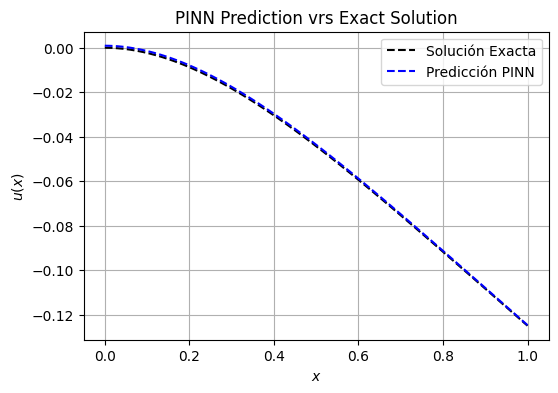

In [37]:
x_values_pinn = np.linspace(0,1,100).reshape(-1,1)
y_pred        = model.predict(x_values_pinn)

x_values_exact = np.linspace(0,1,200).reshape(-1,1)
y_exact        = func(x_values_exact)


plt.figure(figsize=(6,4))
plt.plot(x_values_exact,y_exact,'--k',label="Solución Exacta")

plt.plot(x_values_pinn,y_pred,'--b',label="Predicción PINN")

plt.xlabel("$x$")
plt.ylabel("$u(x)$")
plt.title("PINN Prediction vrs Exact Solution")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# error Method of DirichletBC

In [38]:
X_boundary = np.array([[0.0]])
inputs  = tr.tensor(X_boundary, dtype=tr.float32)
outputs = tr.tensor(model.predict(X_boundary),dtype=tr.float32)

In [40]:
# Indices for boundary points
beg, end = 0, len(X_boundary)


residual_left_tf = bc_dbc.error(X_boundary, inputs, outputs, beg, end)
residual_left    = tr.tensor(residual_left_tf.numpy(), dtype=tr.float32)


mse_residual = tr.mean(residual_left**2) # Este es el que se minimiza
print("MSE of boundary residual for Dirichlet condition:", mse_residual.item())

MSE of boundary residual for Dirichlet condition: 8.191457823158999e-07
